<a href="https://colab.research.google.com/github/samarthya04/AD_Lab/blob/main/2205498_Week_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

In [2]:
# Load Diabetes Dataset
data = pd.read_csv("diabetes.csv")  # Ensure the dataset file is available
X = data.drop(columns=['Outcome'])  # Features
y = data['Outcome']  # Target

In [3]:
# Standardization (Z-score normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
# Split the dataset before applying PCA
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [5]:
# k-NN classification (without PCA)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)  # k=5 chosen empirically
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred)
print(f'Accuracy without PCA: {accuracy_knn:.4f}')

Accuracy without PCA: 0.6883


In [6]:
def apply_pca(X_train, X_test, variance_threshold=0.95):
    # Apply PCA
    pca = PCA()
    pca.fit(X_train)

    # Compute cumulative variance
    explained_variance = np.cumsum(pca.explained_variance_ratio_)
    num_components = np.argmax(explained_variance >= variance_threshold) + 1
    print(f'Number of principal components selected: {num_components}')

    # Apply PCA with selected components
    pca = PCA(n_components=num_components)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    return X_train_pca, X_test_pca, explained_variance, num_components

# Apply PCA
X_train_pca, X_test_pca, explained_variance, num_components = apply_pca(X_train, X_test)

Number of principal components selected: 7


In [7]:
# k-NN classification (with PCA)
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)
y_pred_pca = knn_pca.predict(X_test_pca)
accuracy_knn_pca = accuracy_score(y_test, y_pred_pca)
print(f'Accuracy with PCA: {accuracy_knn_pca:.4f}')

Accuracy with PCA: 0.7078


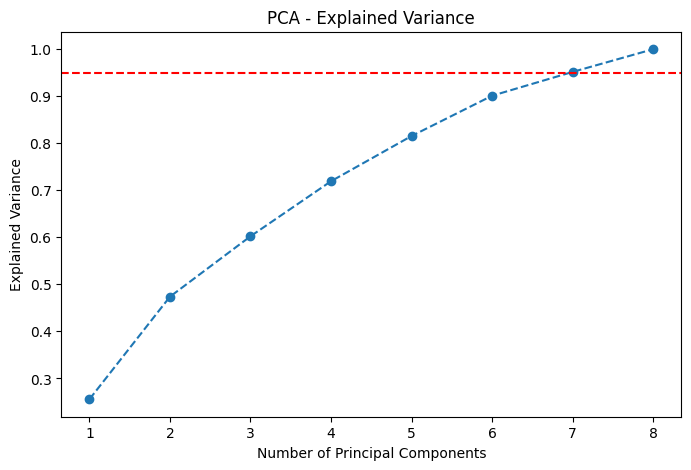

In [8]:
# Plot cumulative variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance')
plt.title('PCA - Explained Variance')
plt.show()

# Conclusion
Applying PCA to the diabetes dataset reduced the number of features from 8 to 7 while retaining 95% of the variance. This dimensionality reduction led to a slight improvement in k-NN accuracy from 68.83% to 70.78%, indicating that PCA helped remove noise and redundant information.